# Forecasting Norwegian Salmon Export Prices

### Predictive Analytics — Exam Project


## 1. Packages


In [1]:
pkgs <- c("fpp3", "tseries", "urca", "strucchange",
          "vars", "PxWebApiData", "ISOweek", "gridExtra")
install.packages(pkgs, repos = "https://cloud.r-project.org")



The downloaded binary packages are in
	/var/folders/6j/b4wy0zfd4pz3bll6wgnctz9m0000gn/T//RtmpHrIBnB/downloaded_packages


In [2]:
library(fpp3)
library(tseries)
library(urca)
library(strucchange)
library(vars)
library(PxWebApiData)
library(ISOweek)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(knitr)


── Attaching packages ──────────────────────────────────────────── fpp3 1.0.3 ──

✔ tibble      3.3.0     ✔ tsibble     1.2.0
✔ dplyr       1.2.0     ✔ tsibbledata 0.4.1
✔ tidyr       1.3.1     ✔ ggtime      0.2.0
✔ lubridate   1.9.5     ✔ feasts      0.5.0
✔ ggplot2     4.0.2     ✔ fable       0.5.0

── Conflicts ───────────────────────────────────────────────── fpp3_conflicts ──
✖ lubridate::date()    masks base::date()
✖ dplyr::filter()      masks stats::filter()
✖ tsibble::intersect() masks base::intersect()
✖ tsibble::interval()  masks lubridate::interval()
✖ dplyr::lag()         masks stats::lag()
✖ tsibble::setdiff()   masks base::setdiff()
✖ tsibble::union()     masks base::union()

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: zoo


Attaching package: ‘zoo’


The following object is masked from ‘package:tsibble’:

    index


The following objects are masked from ‘package:base’:

    as.Date, as.Dat

## 2. Data

Weekly SSB Table 03024 data aggregated to monthly frequency (weight summed, price averaged).


In [3]:
salmon_raw <- ApiData(
  "https://data.ssb.no/api/v0/en/table/03024",
  Tid          = TRUE,
  ContentsCode = c("Weight (tonnes)", "Price per kilo (NOK)")
)

salmon_long <- salmon_raw[[1]] %>%
  rename(week_str = week) %>%
  mutate(
    year  = as.integer(substr(week_str, 1, 4)),
    wnum  = as.integer(sub(".*U", "", week_str)),
    date  = ISOweek2date(sprintf("%04d-W%02d-1", year, wnum)),
    Month = yearmonth(date)
  )

weight_monthly <- salmon_long %>%
  filter(contents == "Weight (tonnes)") %>%
  group_by(Month) %>%
  summarise(weight = sum(value, na.rm = TRUE), .groups = "drop")

price_monthly <- salmon_long %>%
  filter(contents == "Price per kilo (NOK)") %>%
  group_by(Month) %>%
  summarise(price = mean(value, na.rm = TRUE), .groups = "drop")

salmon <- weight_monthly %>%
  left_join(price_monthly, by = "Month") %>%
  filter(Month >= yearmonth("2000 Jan"),
         Month <= yearmonth("2026 Apr")) %>%
  as_tsibble(index = Month) %>%
  mutate(
    log_price  = log(price),
    log_weight = log(weight)
  )

cat("Sample period:", format(min(salmon$Month)), "-", format(max(salmon$Month)), "\n")
cat("Observations :", nrow(salmon), "\n")
tail(salmon)





Sample period: 2000 jan. - 2026 apr. 
Observations : 316 


Month,weight,price,log_price,log_weight
<mth>,<dbl>,<dbl>,<dbl>,<dbl>
2025 nov.,98225,78.63750,4.364849,11.49502
2025 des.,100740,86.15000,4.456090,11.52030
2026 jan.,86621,78.60750,4.364467,11.36930
2026 feb.,77327,79.29250,4.373144,11.25580
2026 mar.,92314,81.25900,4.397642,11.43295
2026 apr.,77634,77.43125,4.349390,11.25976


## 3. Transformation

Guerrero method to confirm log transformation is appropriate (lambda near 0).


In [4]:
lambda_p <- salmon %>%
  features(price, features = guerrero) %>%
  pull(lambda_guerrero)
cat(sprintf("Guerrero lambda (price) = %.3f\n", lambda_p))


Guerrero lambda (price) = 0.049


## 4. Preliminary Visual Analysis


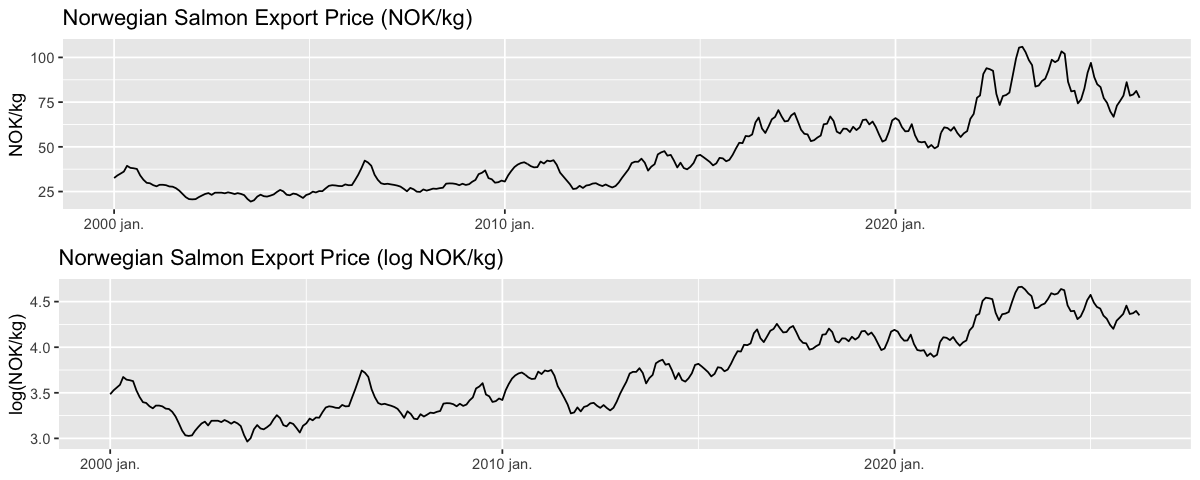

In [5]:
options(repr.plot.width = 10, repr.plot.height = 4)
p1 <- autoplot(salmon, price) +
  labs(title = "Norwegian Salmon Export Price (NOK/kg)", y = "NOK/kg", x = NULL)
p2 <- autoplot(salmon, log_price) +
  labs(title = "Norwegian Salmon Export Price (log NOK/kg)", y = "log(NOK/kg)", x = NULL)
gridExtra::grid.arrange(p1, p2, ncol = 1)


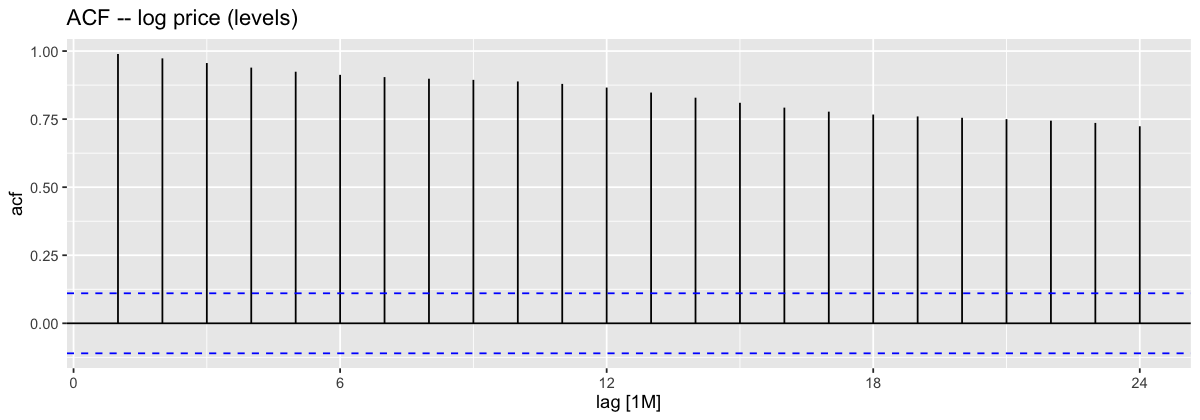

In [6]:
options(repr.plot.width = 10, repr.plot.height = 3.5)
salmon %>% ACF(log_price) %>% autoplot() +
  ggtitle("ACF -- log price (levels)")


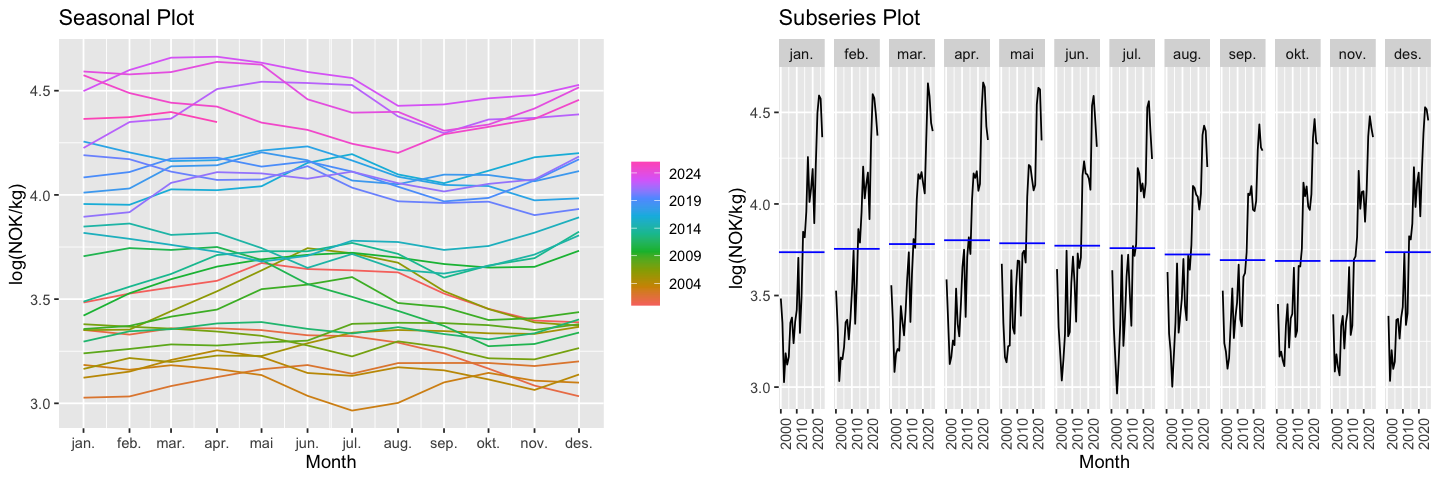

In [7]:
options(repr.plot.width = 12, repr.plot.height = 4)
p1 <- gg_season(salmon, log_price) +
  labs(title = "Seasonal Plot", y = "log(NOK/kg)")
p2 <- gg_subseries(salmon, log_price) +
  labs(title = "Subseries Plot", y = "log(NOK/kg)")
gridExtra::grid.arrange(p1, p2, ncol = 2)


## 5. STL Decomposition


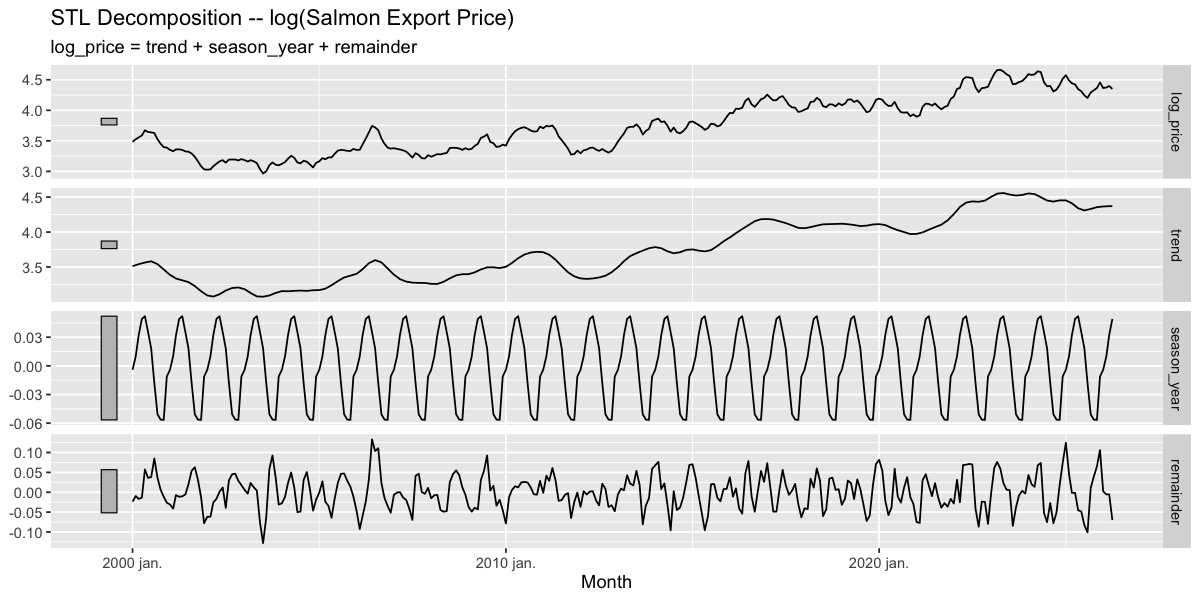

In [8]:
options(repr.plot.width = 10, repr.plot.height = 5)
salmon %>%
  model(stl = STL(log_price ~ trend(window = 13) + season(window = "periodic"))) %>%
  components() %>%
  autoplot() +
  labs(title = "STL Decomposition -- log(Salmon Export Price)")


## 6. Stationarity Tests — Levels

ADF (H0: unit root) and KPSS (H0: stationary) applied to log price in levels.


In [9]:
adf_lev <- ur.df(as.ts(salmon %>% dplyr::select(log_price)),
                 type = "trend", lag = 24, selectlags = "AIC")
summary(adf_lev)



############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.123876 -0.032235  0.003184  0.031459  0.144800 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.2959015  0.0718716   4.117 5.08e-05 ***
z.lag.1      -0.1006133  0.0247827  -4.060 6.41e-05 ***
tt            0.0004993  0.0001297   3.851 0.000146 ***
z.diff.lag1   0.3140089  0.0583814   5.379 1.61e-07 ***
z.diff.lag2   0.0247666  0.0610086   0.406 0.685092    
z.diff.lag3   0.0700336  0.0606442   1.155 0.249163    
z.diff.lag4  -0.0140907  0.0611453  -0.230 0.817916    
z.diff.lag5  -0.0147562  0.0615121  -0.240 0.810593    
z.diff.lag6  -0.0050835  0.0607683  -0.084 0.933392    
z.diff.lag7   0.0223389  0.0607010   0.368 0.713145    
z.diff.lag8  -0.055830

In [10]:
kpss_lev <- ur.kpss(as.ts(salmon %>% dplyr::select(log_price)), type = "tau")
summary(kpss_lev)



####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: tau with 5 lags. 

Value of test-statistic is: 0.3451 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.119 0.146  0.176 0.216


## 7. First Differencing — Stationarity Tests

ADF and KPSS applied to first-differenced log price.


In [11]:
salmon <- salmon %>%
  mutate(
    d_log_price  = difference(log_price),
    d_log_weight = difference(log_weight)
  )

kpss_diff <- ur.kpss(
  salmon %>% dplyr::select(d_log_price) %>% as.ts(), type = "mu")
summary(kpss_diff)



####################### 
# KPSS Unit Root Test # 
####################### 

Test is of type: mu with 5 lags. 

Value of test-statistic is: 0.0634 

Critical value for a significance level of: 
                10pct  5pct 2.5pct  1pct
critical values 0.347 0.463  0.574 0.739


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


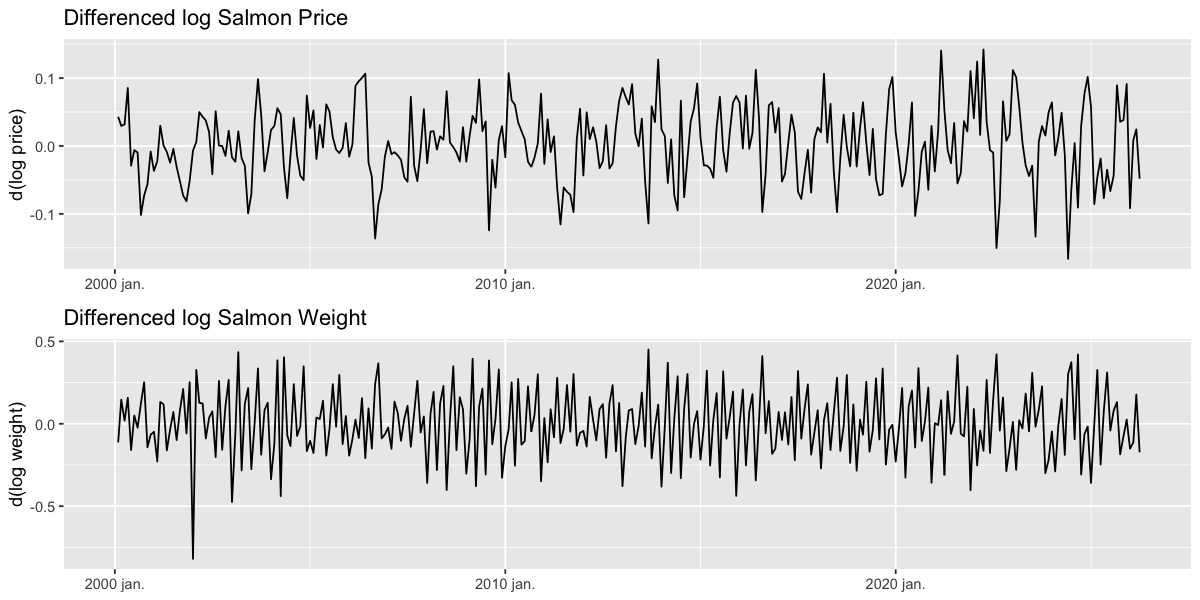

In [12]:
options(repr.plot.width = 10, repr.plot.height = 5)
p1 <- autoplot(salmon, d_log_price) +
  labs(title = "Differenced log Salmon Price", y = "d(log price)", x = NULL)
p2 <- autoplot(salmon, d_log_weight) +
  labs(title = "Differenced log Salmon Weight", y = "d(log weight)", x = NULL)
gridExtra::grid.arrange(p1, p2, ncol = 1)


In [13]:
adf_diff <- ur.df(
  salmon %>% dplyr::select(d_log_price) %>%
    filter(!is.na(d_log_price)) %>% as.ts(),
  type = "none", lag = 24, selectlags = "AIC")
summary(adf_diff)



############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression none 


Call:
lm(formula = z.diff ~ z.lag.1 - 1 + z.diff.lag)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.144846 -0.028918  0.005457  0.033169  0.160074 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
z.lag.1      -0.814170   0.181195  -4.493 1.03e-05 ***
z.diff.lag1   0.099057   0.177197   0.559  0.57660    
z.diff.lag2   0.069251   0.170604   0.406  0.68512    
z.diff.lag3   0.079631   0.161171   0.494  0.62164    
z.diff.lag4   0.008673   0.151005   0.057  0.95424    
z.diff.lag5  -0.062751   0.138463  -0.453  0.65076    
z.diff.lag6  -0.113820   0.127544  -0.892  0.37295    
z.diff.lag7  -0.133456   0.115678  -1.154  0.24963    
z.diff.lag8  -0.228288   0.104608  -2.182  0.02993 *  
z.diff.lag9  -0.157483   0.095104  -1.656  0.09887 .  
z.diff.lag10 -0.153192   0.084870  -1.8

## 8. Structural Break Test (QLR / sup-F)

Applied to first-differenced log price. Trim = 15% each end.


sup-F p-value: 0.6226 


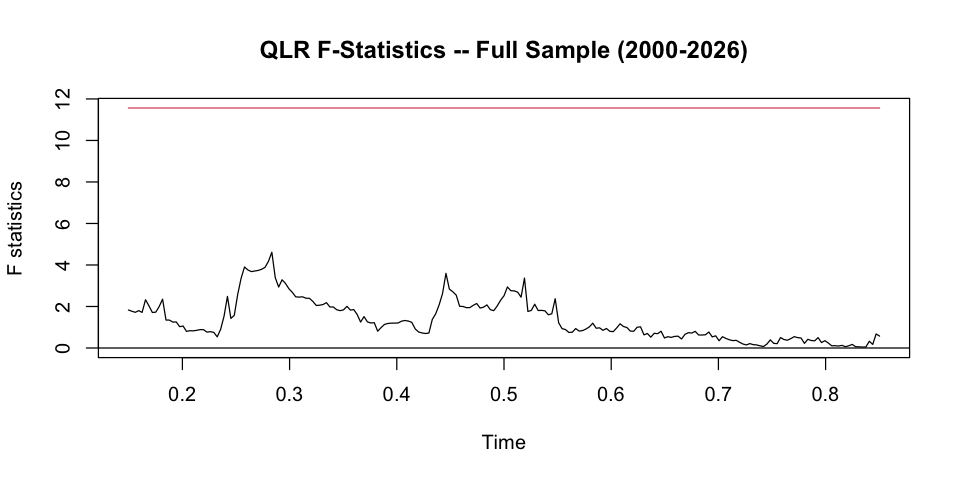

In [14]:
d_ts <- salmon %>%
  dplyr::select(d_log_price) %>%
  filter(!is.na(d_log_price)) %>%
  as.ts()

break_ts  <- cbind(Lag0 = d_ts, Lag1 = stats::lag(d_ts, -1))
qlr       <- Fstats(Lag0 ~ 1 + Lag1, data = break_ts, from = 0.15)
test_full <- sctest(qlr, type = "supF")

options(repr.plot.width = 8, repr.plot.height = 4)
plot(qlr, alpha = 0.05, main = "QLR F-Statistics -- Full Sample (2000-2026)")

cat("sup-F p-value:", round(test_full$p.value, 4), "\n")


## 9. ACF and PACF — ARIMA Identification

Inspecting the differenced series to identify candidate ARIMA orders.


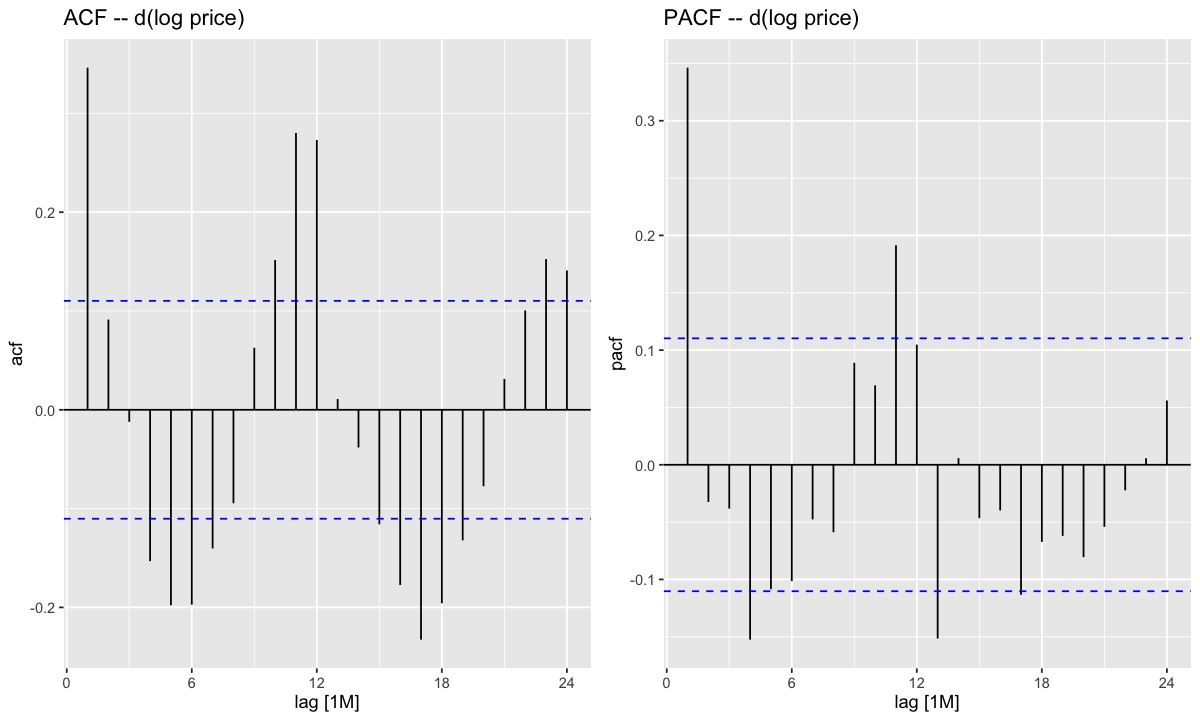

In [15]:
options(repr.plot.width = 10, repr.plot.height = 6)
p1 <- salmon %>% ACF(d_log_price)  %>% autoplot() + ggtitle("ACF -- d(log price)")
p2 <- salmon %>% PACF(d_log_price) %>% autoplot() + ggtitle("PACF -- d(log price)")
gridExtra::grid.arrange(p1, p2, ncol = 2)


## 10. Granger Causality Test

H0: the variable does NOT Granger-cause the other. Tested at the BIC-selected VAR lag (with `lag.max = 24`) so the test is consistent with the VAR specification used later. Result informs whether VAR is statistically justified over univariate models.


In [16]:
granger_data <- salmon %>%
  filter(!is.na(d_log_price) & !is.na(d_log_weight)) %>%
  as_tibble() %>%
  dplyr::select(d_log_price, d_log_weight) %>%
  as.ts()

# Select the lag using BIC on the training portion (same lag will be used for VAR).
# lag.max = 24 avoids the boundary artefact of lag.max = 12 hitting the ceiling.
granger_mat <- salmon %>%
  filter_index(. ~ "2022 M12") %>%
  filter(!is.na(d_log_price) & !is.na(d_log_weight)) %>%
  as_tibble() %>%
  dplyr::select(d_log_price, d_log_weight) %>%
  as.matrix()

vsel_granger <- VARselect(granger_mat, lag.max = 24, type = "const")
cat("Lag order by criterion (lag.max = 24):\n")
print(vsel_granger$selection)

p_granger <- as.integer(vsel_granger$selection["SC(n)"])
cat("\nLag used for Granger test (BIC/SC):", p_granger, "\n\n")

cat("=== Does volume Granger-cause price? ===\n")
print(grangertest(d_log_price ~ d_log_weight, order = p_granger, data = granger_data))

cat("\n=== Does price Granger-cause volume? ===\n")
print(grangertest(d_log_weight ~ d_log_price, order = p_granger, data = granger_data))

Lag order by criterion (lag.max = 24):
AIC(n)  HQ(n)  SC(n) FPE(n) 
    15     15     11     15 

Lag used for Granger test (BIC/SC): 11 

=== Does volume Granger-cause price? ===
Granger causality test

Model 1: d_log_price ~ Lags(d_log_price, 1:11) + Lags(d_log_weight, 1:11)
Model 2: d_log_price ~ Lags(d_log_price, 1:11)
  Res.Df  Df      F   Pr(>F)   
1    281                       
2    292 -11 2.9389 0.001068 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

=== Does price Granger-cause volume? ===
Granger causality test

Model 1: d_log_weight ~ Lags(d_log_weight, 1:11) + Lags(d_log_price, 1:11)
Model 2: d_log_weight ~ Lags(d_log_weight, 1:11)
  Res.Df  Df      F   Pr(>F)   
1    281                       
2    292 -11 2.3893 0.007639 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## 11. Train/Test Split


In [17]:
train <- salmon %>% filter_index(. ~ "2022 M12")
test  <- salmon %>% filter_index("2023 M1" ~ .)

cat("Training observations:", nrow(train), "\n")
cat("Test observations    :", nrow(test),  "\n")


Training observations: 276 
Test observations    : 40 


## 12. Model Estimation

### 12.1 ARIMA and ETS

All models are fitted on `log_price` (same response variable -- required by fable for a single mable). Auto ARIMA uses `stepwise = FALSE, approximation = FALSE` for a thorough search. ETS is restricted to additive errors/trend/seasonality: applying multiplicative errors to already-log-transformed data is a double transformation that previously caused residual autocorrelation. Additive ETS on log values is the standard fpp3 specification for strictly positive data.


In [18]:
models_uni <- train %>%
  model(
    arima_auto   = ARIMA(log_price, stepwise = FALSE, approximation = FALSE),
    arima_manual = ARIMA(log_price ~ pdq(0, 1, 1) + PDQ(1, 0, 0)),
    ets          = ETS(log_price ~ error("A") + trend("A") + season("A"))
  )

cat("=== Auto ARIMA ===\n")
models_uni %>% dplyr::select(arima_auto) %>% report()

=== Auto ARIMA ===
Series: log_price 
Model: ARIMA(2,1,1)(1,0,0)[12] 

Coefficients:
         ar1     ar2      ma1    sar1
      1.3138  -0.377  -0.9600  0.2786
s.e.  0.0602   0.056   0.0268  0.0617

sigma^2 estimated as 0.002293:  log likelihood=446.96
AIC=-883.92   AICc=-883.69   BIC=-865.83


In [19]:
cat("=== Manual ARIMA ===\n")
models_uni %>% dplyr::select(arima_manual) %>% report()


=== Manual ARIMA ===
Series: log_price 
Model: ARIMA(0,1,1)(1,0,0)[12] 

Coefficients:
         ma1    sar1
      0.3194  0.2674
s.e.  0.0510  0.0609

sigma^2 estimated as 0.002352:  log likelihood=442.54
AIC=-879.09   AICc=-879   BIC=-868.24


In [20]:
cat("=== ETS ===\n")
models_uni %>% dplyr::select(ets) %>% report()


=== ETS ===
Series: log_price 
Model: ETS(A,A,A) 
  Smoothing parameters:
    alpha = 0.9368528 
    beta  = 0.0001459981 
    gamma = 0.06314363 

  Initial states:
     l[0]        b[0]         s[0]       s[-1]       s[-2]       s[-3]
 3.496679 0.001486869 -0.002473271 -0.05506226 -0.02408102 -0.01468678
        s[-4]        s[-5]      s[-6]     s[-7]      s[-8]       s[-9]
 -0.006595482 -0.007002437 0.02736084 0.0334101 0.03392231 0.005529406
      s[-10]     s[-11]
 -0.00046774 0.01014633

  sigma^2:  0.0026

      AIC      AICc       BIC 
-72.17401 -69.80192 -10.62720 


### 12.2 VAR

Lag selection via `VARselect` with `lag.max = 24` (avoids the boundary artefact of `lag.max = 12` on monthly data, where criteria can hit the ceiling). VAR is estimated on the stationary (differenced) series. BIC (SC) is preferred for parsimony.


In [21]:
train_mat <- train %>%
  filter(!is.na(d_log_price) & !is.na(d_log_weight)) %>%
  as_tibble() %>%
  dplyr::select(d_log_price, d_log_weight) %>%
  as.matrix()

# lag.max = 24 (was 12) -- avoids boundary artefact where criteria hit the ceiling.
var_select <- VARselect(train_mat, lag.max = 24, type = "const")
cat("Lag order by criterion (lag.max = 24):\n")
print(var_select$selection)

# BIC (SC) preferred for parsimony.
p_bic   <- as.integer(var_select$selection["SC(n)"])
var_fit <- VAR(train_mat, p = p_bic, type = "const")
cat("\nVAR fitted with p =", p_bic, "lags (BIC choice)\n")

Lag order by criterion (lag.max = 24):
AIC(n)  HQ(n)  SC(n) FPE(n) 
    15     15     11     15 

VAR fitted with p = 11 lags (BIC choice)


In [22]:
summary(var_fit$varresult$d_log_price)



Call:
lm(formula = y ~ -1 + ., data = datamat)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.115464 -0.031970 -0.001011  0.031446  0.111869 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
d_log_price.l1    0.272220   0.065646   4.147 4.67e-05 ***
d_log_weight.l1   0.036835   0.022261   1.655 0.099296 .  
d_log_price.l2   -0.029491   0.068125  -0.433 0.665476    
d_log_weight.l2   0.019032   0.027372   0.695 0.487528    
d_log_price.l3   -0.017108   0.069177  -0.247 0.804877    
d_log_weight.l3   0.039811   0.029907   1.331 0.184398    
d_log_price.l4    0.012022   0.068552   0.175 0.860938    
d_log_weight.l4   0.094663   0.029052   3.258 0.001282 ** 
d_log_price.l5    0.042697   0.068400   0.624 0.533072    
d_log_weight.l5   0.125199   0.031665   3.954 0.000101 ***
d_log_price.l6    0.043971   0.068834   0.639 0.523560    
d_log_weight.l6   0.109106   0.033595   3.248 0.001329 ** 
d_log_price.l7    0.112153   0.068742   1.632 0.104087  

## 13. Residual Diagnostics

### 13.1 ARIMA


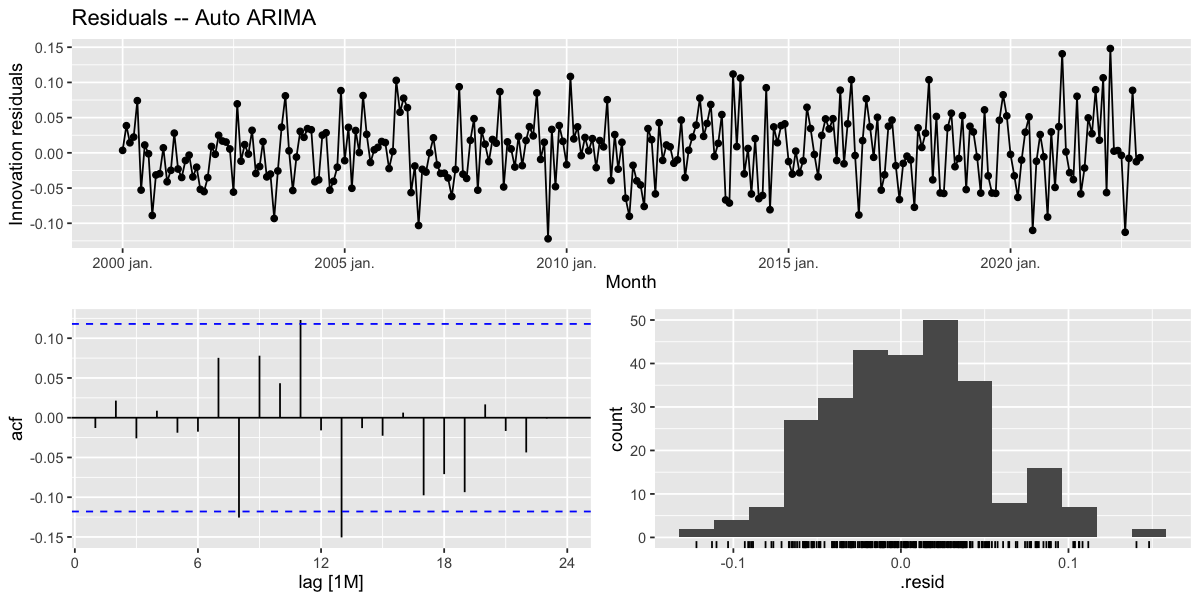

In [23]:
options(repr.plot.width = 10, repr.plot.height = 5)
models_uni %>%
  dplyr::select(arima_auto) %>%
  gg_tsresiduals(type = "innovation") +
  ggtitle("Residuals -- Auto ARIMA")


### 13.2 ETS


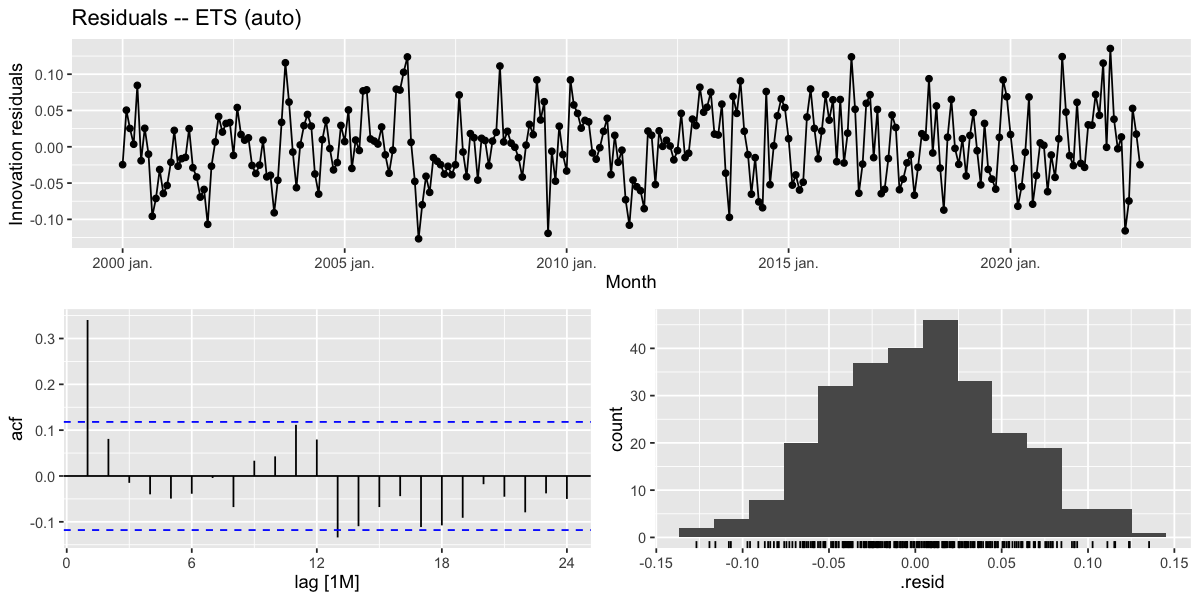

In [24]:
options(repr.plot.width = 10, repr.plot.height = 5)
models_uni %>%
  dplyr::select(ets) %>%
  gg_tsresiduals(type = "innovation") +
  ggtitle("Residuals -- ETS (auto)")


### 13.3 Ljung-Box Tests — ARIMA and ETS

dof = number of estimated parameters. H0: residuals are white noise.


In [25]:
# Get actual model names dynamically from report()
arima_name <- models_uni %>% dplyr::select(arima_auto) %>%
  report() %>% capture.output() %>% grep("Model:", ., value = TRUE) %>%
  sub("Model: ", "", .)

ets_name <- models_uni %>% dplyr::select(ets) %>%
  report() %>% capture.output() %>% grep("Model:", ., value = TRUE) %>%
  sub("Model: ", "", .)

# dof = number of estimated parameters (recovered from tidy()).
arima_dof <- models_uni %>% dplyr::select(arima_auto) %>% tidy() %>% nrow()
ets_dof   <- models_uni %>% dplyr::select(ets)        %>% tidy() %>% nrow()

cat("ARIMA dof =", arima_dof, " | ETS dof =", ets_dof, "\n\n")

# Use .innov (innovation residuals) -- standard for both ARIMA and ETS in fable,
# and consistent with the curriculum (PS7/PS8 solutions use .innov).
# lag = 24 is the recommended choice for monthly data.
lb_results <- bind_rows(
  augment(models_uni %>% dplyr::select(arima_auto)) %>%
    features(.innov, ljung_box, lag = 24, dof = arima_dof) %>%
    mutate(model = arima_name),
  augment(models_uni %>% dplyr::select(ets)) %>%
    features(.innov, ljung_box, lag = 24, dof = ets_dof) %>%
    mutate(model = ets_name)
) %>%
  dplyr::select(model, lb_stat, lb_pvalue)

print(lb_results)

ARIMA dof = 4  | ETS dof = 17 

# A tibble: 2 × 3
  model                      lb_stat lb_pvalue
  <chr>                        <dbl>     <dbl>
1 "ARIMA(2,1,1)(1,0,0)[12] "    28.0  1.10e- 1
2 "ETS(A,A,A) "                 67.5  4.71e-12


### 13.4 VAR — Residual Diagnostics


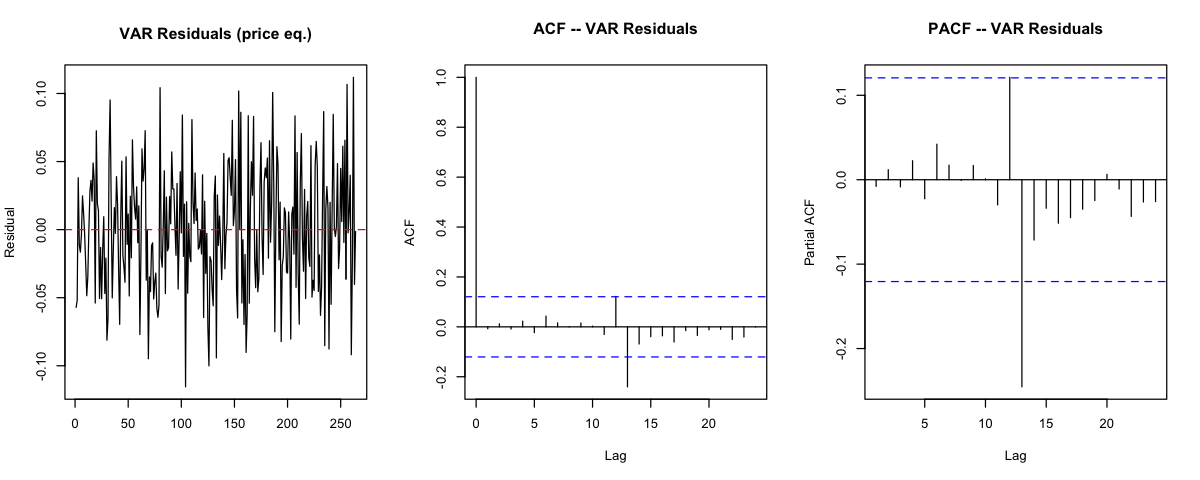

In [26]:
var_resid <- residuals(var_fit)[, "d_log_price"]

options(repr.plot.width = 10, repr.plot.height = 4)
par(mfrow = c(1, 3))
plot(var_resid, type = "l", main = "VAR Residuals (price eq.)",
     ylab = "Residual", xlab = "")
abline(h = 0, col = "red", lty = 2)
acf(var_resid,  main = "ACF -- VAR Residuals")
pacf(var_resid, main = "PACF -- VAR Residuals")
par(mfrow = c(1, 1))


In [27]:
# Multivariate portmanteau test — H0: no serial correlation in VAR residuals
serial_test <- serial.test(var_fit, lags.pt = 24, type = "PT.asymptotic")
print(serial_test)



	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_fit
Chi-squared = 85.832, df = 52, p-value = 0.002184



$serial

	Portmanteau Test (asymptotic)

data:  Residuals of VAR object var_fit
Chi-squared = 85.832, df = 52, p-value = 0.002184



## 14. Test-Set Forecasts (evaluation period: 2023–april 2026)


In [28]:
h <- nrow(test)

# Univariate ARIMA/ETS forecasts via fable on log_price.
forc_uni <- models_uni %>%
  forecast(new_data = test %>% dplyr::select(log_price))

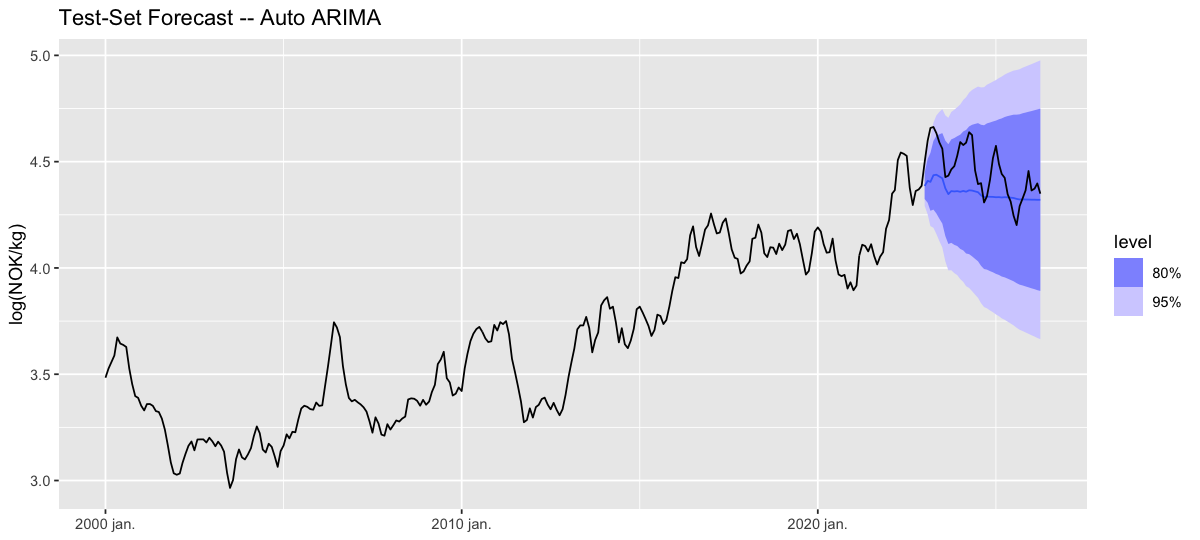

In [29]:
options(repr.plot.width = 10, repr.plot.height = 4.5)
forc_uni %>%
  filter(.model == "arima_auto") %>%
  autoplot(salmon %>% dplyr::select(log_price)) +
  labs(title = "Test-Set Forecast -- Auto ARIMA", y = "log(NOK/kg)", x = NULL)

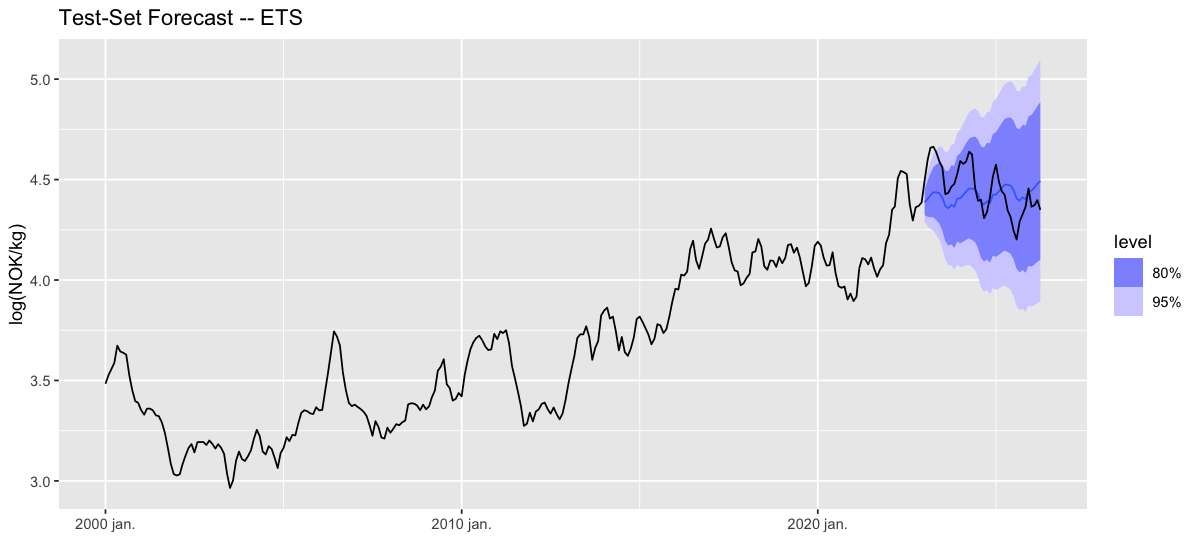

In [30]:
options(repr.plot.width = 10, repr.plot.height = 4.5)
forc_uni %>%
  filter(.model == "ets") %>%
  autoplot(salmon %>% dplyr::select(log_price)) +
  labs(title = "Test-Set Forecast -- ETS", y = "log(NOK/kg)", x = NULL)

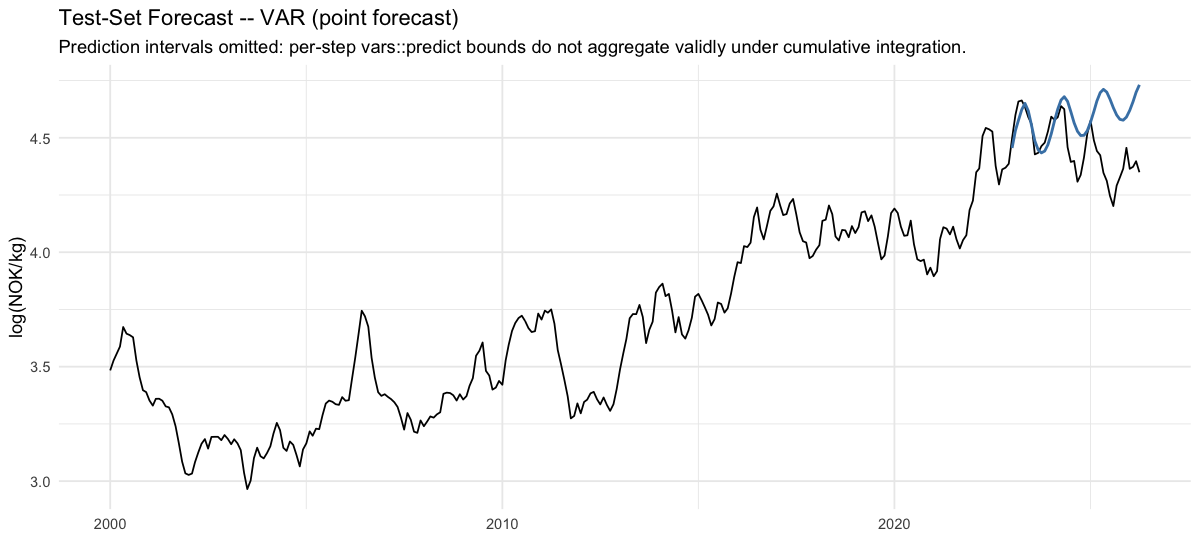

In [31]:
var_pred <- predict(var_fit, n.ahead = h)
last_lp  <- train %>% filter(!is.na(log_price)) %>% tail(1) %>% pull(log_price)

d_hat <- var_pred$fcst$d_log_price[, "fcst"]

var_forc_df <- tibble(
  Month    = test$Month,
  forecast = last_lp + cumsum(d_hat)
)

# Plot: point forecast only. The per-step CIs from vars::predict() do not aggregate
# correctly to a cumulative-integration forecast in levels, so we omit bands.
options(repr.plot.width = 10, repr.plot.height = 4.5)
salmon %>%
  as_tibble() %>%
  ggplot(aes(x = as.Date(Month), y = log_price)) +
  geom_line() +
  geom_line(data = var_forc_df,
            aes(x = as.Date(Month), y = forecast),
            inherit.aes = FALSE, colour = "steelblue", linewidth = 0.8) +
  labs(title    = "Test-Set Forecast -- VAR (point forecast)",
       subtitle = "Prediction intervals omitted: per-step vars::predict bounds do not aggregate validly under cumulative integration.",
       y = "log(NOK/kg)", x = NULL) +
  theme_minimal()

## 15. Forecast Accuracy Comparison

All metrics computed on the hold-out test set on the **log scale** (the scale all three models are estimated on). MASE benchmark is the seasonal-naive model on the training data; MASE < 1 beats the benchmark. MAPE is **omitted** because percentage error on log values is not interpretable as a percentage error in NOK/kg.


In [32]:
# Univariate ARIMA/ETS accuracy on log scale
acc_uni <- accuracy(forc_uni, salmon %>% dplyr::select(log_price)) %>%
  dplyr::select(.model, RMSE, MAE, MASE)

# VAR accuracy on log scale: actual log_price vs reconstructed level forecast.
actual_lp <- test$log_price
var_err   <- actual_lp - var_forc_df$forecast

# MASE benchmark: average absolute seasonal-naive error on training log_price
snaive_scale <- train %>%
  as_tibble() %>%
  dplyr::select(Month, log_price) %>%
  mutate(snaive_err = log_price - lag(log_price, 12)) %>%
  pull(snaive_err) %>%
  abs() %>%
  mean(na.rm = TRUE)

var_acc <- tibble(
  .model = "var",
  RMSE   = sqrt(mean(var_err^2, na.rm = TRUE)),
  MAE    = mean(abs(var_err),    na.rm = TRUE),
  MASE   = mean(abs(var_err), na.rm = TRUE) / snaive_scale
)

acc_all <- bind_rows(acc_uni, var_acc) %>%
  filter(.model %in% c("arima_auto", "ets", "var")) %>%
  mutate(.model = recode(.model,
                         "arima_auto" = "ARIMA (auto)",
                         "ets"        = "ETS",
                         "var"        = "VAR")) %>%
  arrange(RMSE)

knitr::kable(acc_all, digits = 4,
             caption = "Out-of-sample forecast accuracy (log scale). MASE < 1 beats seasonal naive on training set. MAPE on log values is omitted (not meaningful).")



Table: Out-of-sample forecast accuracy (log scale). MASE < 1 beats seasonal naive on training set. MAPE on log values is omitted (not meaningful).

|.model       |   RMSE|    MAE|   MASE|
|:------------|------:|------:|------:|
|ETS          | 0.1287| 0.1116| 0.6571|
|ARIMA (auto) | 0.1432| 0.1188| 0.6999|
|VAR          | 0.2019| 0.1531| 0.9015|

## 16. Forward Forecast — Next 12 Months (NOK/kg)

Best model re-fitted on full dataset. fpp3 back-transforms automatically when `log(price)` used in formula.


In [33]:
# Re-fit best models on full sample.
# Use log(price) inside the formula so fable auto-back-transforms forecasts to NOK/kg.
models_final <- salmon %>%
  model(
    arima_auto = ARIMA(log(price), stepwise = FALSE, approximation = FALSE),
    ets        = ETS(log(price) ~ error("A") + trend("A") + season("A"))
  )

forc_final <- models_final %>% forecast(h = 12)

Warning message in sqrt(diag(best$var.coef)):
“NaNs produced”


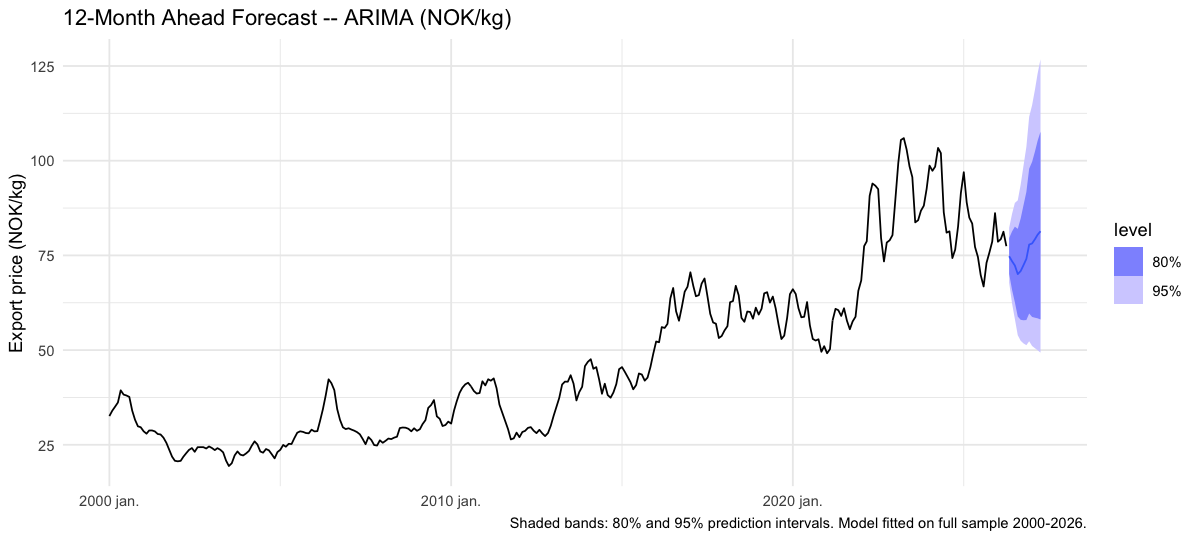

In [34]:
# Plot -- ARIMA (update to "ets" if ETS wins on RMSE)
options(repr.plot.width = 10, repr.plot.height = 4.5)
forc_final %>%
  filter(.model == "arima_auto") %>%
  autoplot(salmon %>% dplyr::select(price)) +
  labs(title   = "12-Month Ahead Forecast -- ARIMA (NOK/kg)",
       y       = "Export price (NOK/kg)",
       x       = NULL,
       caption = "Shaded bands: 80% and 95% prediction intervals. Model fitted on full sample 2000-2026.") +
  theme_minimal()


In [35]:
# Monthly forecast table in NOK/kg
forc_final %>%
  filter(.model == "arima_auto") %>%
  hilo(level = c(80, 95)) %>%
  unpack_hilo(c("80%", "95%")) %>%
  as_tibble() %>%
  transmute(
    Month               = format(Month),
    `Forecast (NOK/kg)` = round(.mean, 1),
    `Lower 80%`         = round(`80%_lower`, 1),
    `Upper 80%`         = round(`80%_upper`, 1),
    `Lower 95%`         = round(`95%_lower`, 1),
    `Upper 95%`         = round(`95%_upper`, 1)
  ) %>%
  knitr::kable(caption = "12-month salmon export price forecast (NOK/kg)",
               align   = "lrrrrr")




Table: 12-month salmon export price forecast (NOK/kg)

|Month     | Forecast (NOK/kg)| Lower 80%| Upper 80%| Lower 95%| Upper 95%|
|:---------|-----------------:|---------:|---------:|---------:|---------:|
|2026 mai  |              74.8|      70.1|      79.6|      67.8|      82.3|
|2026 jun. |              73.5|      65.9|      81.3|      62.3|      86.0|
|2026 jul. |              72.3|      62.6|      82.6|      58.2|      88.9|
|2026 aug. |              70.1|      58.9|      82.0|      53.9|      89.5|
|2026 sep. |              70.9|      58.0|      84.7|      52.5|      93.7|
|2026 okt. |              72.4|      57.9|      88.2|      51.8|      98.6|
|2026 nov. |              74.1|      57.9|      91.8|      51.3|     103.6|
|2026 des. |              77.9|      59.7|      97.9|      52.3|     111.6|
|2027 jan. |              78.2|      58.8|      99.7|      51.1|     114.6|
|2027 feb. |              79.3|      58.5|     102.4|      50.5|     118.8|
|2027 mar. |              80.5|